# 特征工程进阶 - 特征选择和异常值处理

本笔记本演示特征选择方法和异常值检测与处理。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler

plt.rcParams['font.sans-serif'] = ['KaiTi']  # 楷体字
plt.rcParams['axes.unicode_minus'] = False
print("特征工程进阶库已导入")

特征工程进阶库已导入


## 1. 特征选择 - 过滤方法（Filter Methods）

In [2]:
# 创建示例数据
np.random.seed(42)
X = pd.DataFrame({
    '特征1': np.random.randn(100),
    '特征2': np.random.randn(100),
    '特征3': np.random.randn(100),
    '特征4': np.random.randn(100),
    '特征5': np.random.randn(100)
})

# 创建目标变量（与特征1和特征3强相关）
y = (X['特征1'] > 0).astype(int) | (X['特征3'] > 0).astype(int)

print("原始数据 (前5行):")
print(X.head())
print(f"\n特征数: {X.shape[1]}")
print(f"样本数: {X.shape[0]}")

原始数据 (前5行):
        特征1       特征2       特征3       特征4       特征5
0  0.496714 -1.415371  0.357787 -0.828995 -1.594428
1 -0.138264 -0.420645  0.560785 -0.560181 -0.599375
2  0.647689 -0.342715  1.083051  0.747294  0.005244
3  1.523030 -0.802277  1.053802  0.610370  0.046981
4 -0.234153 -0.161286 -1.377669 -0.020902 -0.450065

特征数: 5
样本数: 100


In [3]:
# SelectKBest - 选择前 K 个最优特征
print("\nSelectKBest - 选择前 3 个特征:")
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X, y)

# 获取特征重要性分数
scores = selector.scores_
feature_scores = pd.DataFrame({
    '特征': X.columns,
    '分数': scores
}).sort_values('分数', ascending=False)

print(feature_scores)
print()

# 获取选中的特征
selected_features = X.columns[selector.get_support()].tolist()
print(f"选中的特征: {selected_features}")


SelectKBest - 选择前 3 个特征:
    特征         分数
2  特征3  44.477362
0  特征1  37.580918
4  特征5   4.355892
1  特征2   1.602336
3  特征4   0.106258

选中的特征: ['特征1', '特征3', '特征5']


## 2. 特征选择 - 包装方法（Wrapper Methods）

使用机器学习模型来评估特征的重要性

In [4]:
# 使用 RandomForest 进行特征选择
print("使用 RandomForest 的特征重要性:")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 获取特征重要性
importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    '特征': X.columns,
    '重要性': importances
}).sort_values('重要性', ascending=False)

print(feature_importance)
print()

使用 RandomForest 的特征重要性:
    特征       重要性
2  特征3  0.464994
0  特征1  0.321587
4  特征5  0.095809
1  特征2  0.062704
3  特征4  0.054905



In [5]:
# SelectFromModel - 使用模型进行特征选择
print("SelectFromModel - 选择重要性高于中位数的特征:")
selector_rf = SelectFromModel(rf, prefit=True, threshold='median')
X_selected_rf = selector_rf.transform(X)

selected_features_rf = X.columns[selector_rf.get_support()].tolist()
print(f"选中的特征: {selected_features_rf}")
print(f"原始特征数: {X.shape[1]}, 选中特征数: {X_selected_rf.shape[1]}")

SelectFromModel - 选择重要性高于中位数的特征:
选中的特征: ['特征1', '特征3', '特征5']
原始特征数: 5, 选中特征数: 3


d:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


## 3. 特征重要性可视化

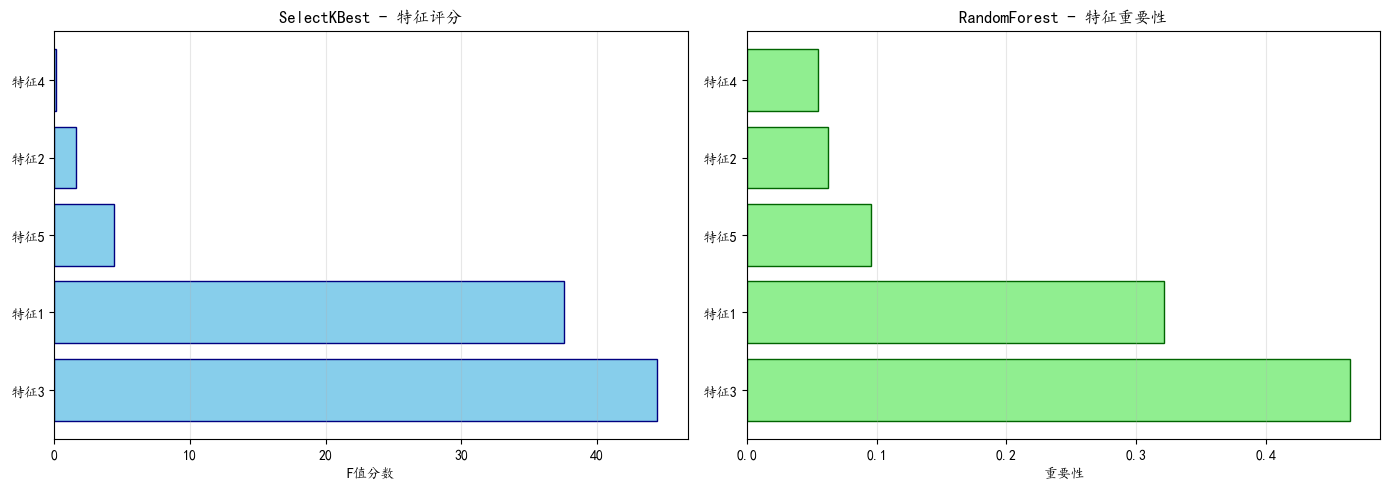

In [6]:
# 绘制特征重要性
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SelectKBest 分数
axes[0].barh(feature_scores['特征'], feature_scores['分数'], color='skyblue', edgecolor='navy')
axes[0].set_xlabel('F值分数')
axes[0].set_title('SelectKBest - 特征评分')
axes[0].grid(True, alpha=0.3, axis='x')

# RandomForest 重要性
axes[1].barh(feature_importance['特征'], feature_importance['重要性'], color='lightgreen', edgecolor='darkgreen')
axes[1].set_xlabel('重要性')
axes[1].set_title('RandomForest - 特征重要性')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 4. 异常值检测 - IQR 方法

In [7]:
# 创建包含异常值的数据
data = pd.DataFrame({
    '销售额': [100, 120, 150, 110, 130, 200, 140, 150, 500, 120, 140]
})

print("原始数据:")
print(data)
print()

# IQR 方法检测异常值
Q1 = data['销售额'].quantile(0.25)
Q3 = data['销售额'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25%): {Q1}")
print(f"Q3 (75%): {Q3}")
print(f"IQR: {IQR}")
print(f"下界: {lower_bound}")
print(f"上界: {upper_bound}")
print()

# 标记异常值
is_outlier = (data['销售额'] < lower_bound) | (data['销售额'] > upper_bound)
data['是否异常'] = is_outlier

print("异常值检测结果:")
print(data)
print(f"\n异常值总数: {is_outlier.sum()}")

原始数据:
    销售额
0   100
1   120
2   150
3   110
4   130
5   200
6   140
7   150
8   500
9   120
10  140

Q1 (25%): 120.0
Q3 (75%): 150.0
IQR: 30.0
下界: 75.0
上界: 195.0

异常值检测结果:
    销售额   是否异常
0   100  False
1   120  False
2   150  False
3   110  False
4   130  False
5   200   True
6   140  False
7   150  False
8   500   True
9   120  False
10  140  False

异常值总数: 2


## 5. 异常值处理方法

In [9]:
# 方法1：删除异常值
print("方法1: 删除异常值")
data_removed = data[~is_outlier].drop('是否异常', axis=1).reset_index(drop=True)
print(f"原始数据行数: {len(data)}, 处理后行数: {len(data_removed)}")
print()

# 方法2：用中位数替换
print("方法2: 用中位数替换异常值")
data_median = data.copy()
median_value = data_median['销售额'].median()
data_median.loc[is_outlier, '销售额'] = median_value
print(data_median.drop('是否异常', axis=1))
print()

# 方法3：用上界/下界替换（截断）
print("方法3: 用上界/下界替换异常值")
data_clipped = data.copy()
data_clipped['销售额'] = data_clipped['销售额'].clip(lower_bound, upper_bound)
print(data_clipped.drop('是否异常', axis=1))

方法1: 删除异常值
原始数据行数: 11, 处理后行数: 9

方法2: 用中位数替换异常值
    销售额
0   100
1   120
2   150
3   110
4   130
5   140
6   140
7   150
8   140
9   120
10  140

方法3: 用上界/下界替换异常值
    销售额
0   100
1   120
2   150
3   110
4   130
5   195
6   140
7   150
8   195
9   120
10  140


## 6. 异常值可视化

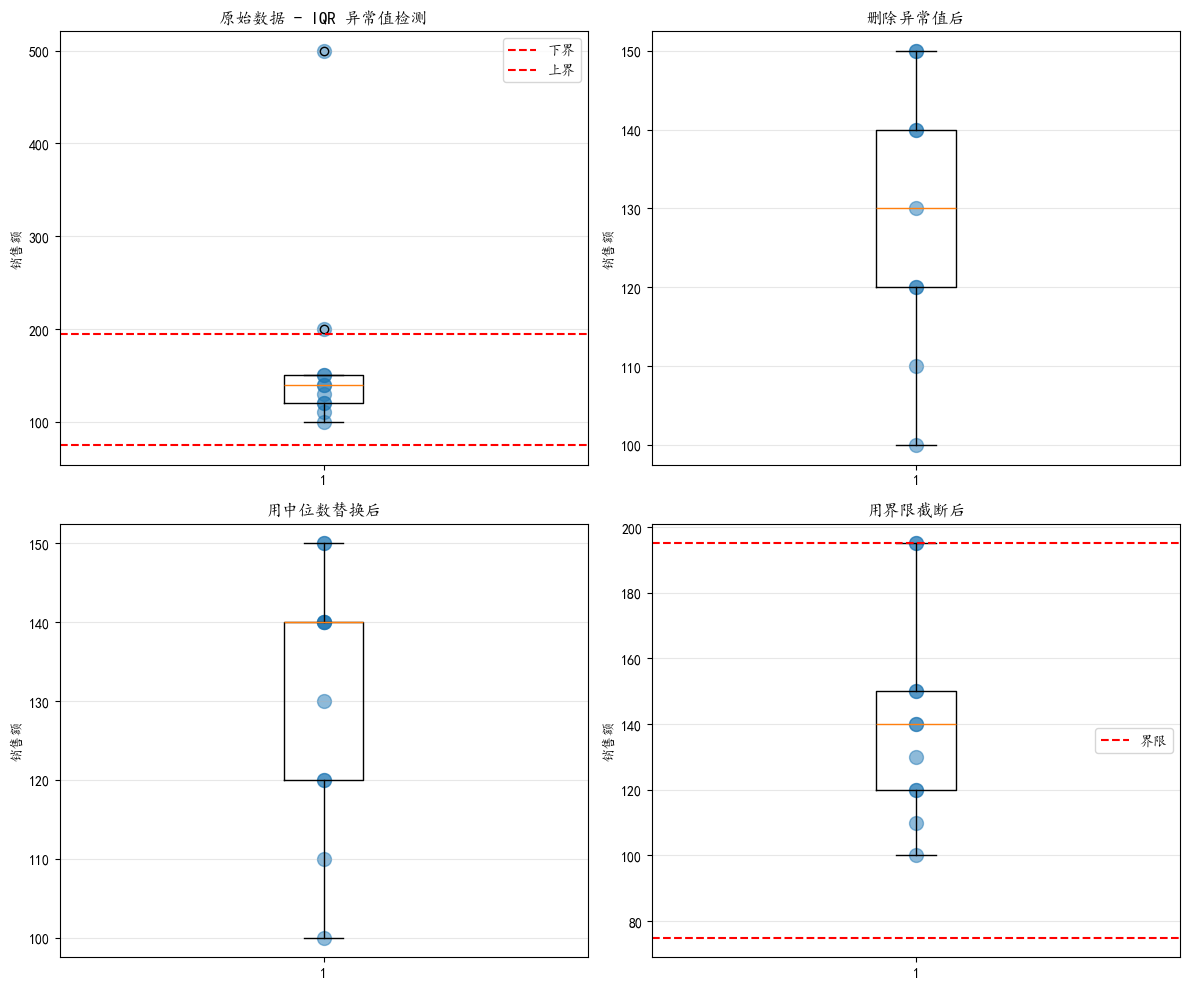

In [10]:
# 绘制异常值检测
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 原始数据箱线图
axes[0, 0].boxplot(data['销售额'], vert=True)
axes[0, 0].scatter(np.ones(len(data)), data['销售额'], alpha=0.5, s=100)
axes[0, 0].axhline(lower_bound, color='r', linestyle='--', label='下界')
axes[0, 0].axhline(upper_bound, color='r', linestyle='--', label='上界')
axes[0, 0].set_ylabel('销售额')
axes[0, 0].set_title('原始数据 - IQR 异常值检测')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 删除后
axes[0, 1].boxplot(data_removed['销售额'], vert=True)
axes[0, 1].scatter(np.ones(len(data_removed)), data_removed['销售额'], alpha=0.5, s=100)
axes[0, 1].set_ylabel('销售额')
axes[0, 1].set_title('删除异常值后')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 中位数替换后
axes[1, 0].boxplot(data_median['销售额'], vert=True)
axes[1, 0].scatter(np.ones(len(data_median)), data_median['销售额'], alpha=0.5, s=100)
axes[1, 0].set_ylabel('销售额')
axes[1, 0].set_title('用中位数替换后')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 截断后
axes[1, 1].boxplot(data_clipped['销售额'], vert=True)
axes[1, 1].scatter(np.ones(len(data_clipped)), data_clipped['销售额'], alpha=0.5, s=100)
axes[1, 1].axhline(lower_bound, color='r', linestyle='--', label='界限')
axes[1, 1].axhline(upper_bound, color='r', linestyle='--')
axes[1, 1].set_ylabel('销售额')
axes[1, 1].set_title('用界限截断后')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Z-Score 异常值检测

In [11]:
from scipy import stats

# 计算 Z-score
z_scores = np.abs(stats.zscore(data['销售额']))
threshold = 3

print(f"Z-Score 检测 (阈值={threshold}):")
print()

outliers_zscore = z_scores > threshold
result_zscore = pd.DataFrame({
    '销售额': data['销售额'],
    'Z-Score': z_scores,
    '是否异常': outliers_zscore
})

print(result_zscore)
print(f"\n异常值总数 (Z-Score): {outliers_zscore.sum()}")

Z-Score 检测 (阈值=3):

    销售额   Z-Score   是否异常
0   100  0.641767  False
1   120  0.455993  False
2   150  0.177330  False
3   110  0.548880  False
4   130  0.363105  False
5   200  0.287106  False
6   140  0.270218  False
7   150  0.177330  False
8   500  3.073728   True
9   120  0.455993  False
10  140  0.270218  False

异常值总数 (Z-Score): 1
